# Machine Learning Project - Password Strength Classifiers

Simone Piras 70/90/00539, Giovanni Presenti 70/90/00556, Alessia Tiddia 70/90/00501

#### Introduction 
This work aims to compare different classifiers for password strength prediction using a dataset of passwords with their respective strength labels.

#### Initial operations

In [3]:
import pandas as pd
import os

# Constants to define the number of training and testing samples
N_TRAIN = 50000
N_TEST = 500000


# Load the dataset
dirname = os.getcwd()
filename = os.path.join(dirname, "Dataset/data.csv")
data = pd.read_csv(filename, on_bad_lines="skip")
# N_TEST =  len(data) - N_TRAIN

#### Feature extraction

In [4]:
import numpy as np


# Shuffle the dataset
data_shuffled = data.sample(frac=1)

# Ensure the 'password' column is treated as string
data_shuffled["password"] = data_shuffled["password"].astype(str)

# Extract features
pass_length_train = data_shuffled["password"].str.len().head(N_TRAIN).values
digits_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_train = (data_shuffled["password"].head(N_TRAIN).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_train = data_shuffled["password"].head(N_TRAIN).apply(lambda x: len(set(x))).values

pass_length_test = data_shuffled["password"].str.len().tail(N_TEST).values
digits_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isdigit()])).values)
symbols_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if not c.isalnum()])).values)
upper_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.isupper()])).values)
lower_test = (data_shuffled["password"].tail(N_TEST).apply(lambda x: len([c for c in x if c.islower()])).values)
unique_chars_test = data_shuffled["password"].tail(N_TEST).apply(lambda x: len(set(x))).values

# Normalize features by password length (avoid division by zero)
digits_train_norm = digits_train / np.where(pass_length_train == 0, 1, pass_length_train)
symbols_train_norm = symbols_train / np.where(pass_length_train == 0, 1, pass_length_train)
upper_train_norm = upper_train / np.where(pass_length_train == 0, 1, pass_length_train)
lower_train_norm = lower_train / np.where(pass_length_train == 0, 1, pass_length_train)
unique_ratio_train = unique_chars_train / np.where(pass_length_train == 0, 1, pass_length_train)

digits_test_norm = digits_test / np.where(pass_length_test == 0, 1, pass_length_test)
symbols_test_norm = symbols_test / np.where(pass_length_test == 0, 1, pass_length_test)
upper_test_norm = upper_test /  np.where(pass_length_test == 0, 1, pass_length_test)
lower_test_norm = lower_test /  np.where(pass_length_test == 0, 1, pass_length_test)
unique_ratio_test = unique_chars_test / np.where(pass_length_test == 0, 1, pass_length_test)

ytr = data_shuffled["strength"].head(N_TRAIN).values
yts = data_shuffled["strength"].tail(N_TEST).values


#### Display Train and Test subsets by password strenght

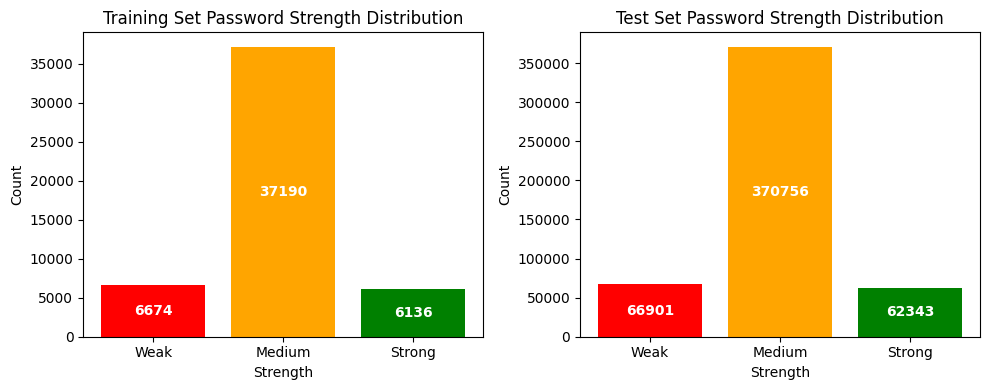

In [5]:
import matplotlib.pyplot as plt

# Display the distribution of password strength in the training and test sets
train_counts = pd.Series(ytr).value_counts().sort_index()
test_counts = pd.Series(yts).value_counts().sort_index()

strength_labels = ["Weak", "Medium", "Strong"]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
bars1 = plt.bar(strength_labels, train_counts, color=["red", "orange", "green"])
plt.title("Training Set Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")
# Add value labels inside the bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{int(height)}", ha="center", va="center", color="white", fontweight="bold",)

plt.subplot(1, 2, 2)
bars2 = plt.bar(strength_labels, test_counts, color=["red", "orange", "green"])
plt.title("Test Set Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")
# Add value labels inside the bars
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{int(height)}", ha="center", va="center", color="white", fontweight="bold",)

plt.tight_layout()
plt.show()

#### Classifiers definition

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Define the classifiers with their parameters
KNN_clf = KNeighborsClassifier(n_neighbors=5)
SVM_clf = SVC(kernel="rbf")
DT_clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
GNB_clf = GaussianNB()
SGD_reg = SGDClassifier(loss="hinge", penalty="l2")

# List of classifiers to be trained and tested
clfs = [KNN_clf, SVM_clf, DT_clf, GNB_clf, SGD_reg]

#### Test with password lenght, number of digits, number of symbols, number of uppercase, number of lowercase and number of unique characters 

In [7]:
import time

# Prepare the training and testing feature sets
xtr = np.array([pass_length_train, digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_ratio_train]).T
xts = np.array([pass_length_test, digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_ratio_test]).T

# Fit each classifier, make predictions, and evaluate performance
def train(xtr,ytr):
    for clf in clfs:

        print("\n")
        print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
        tic = time.perf_counter()
        clf.fit(xtr, ytr)
        toc = time.perf_counter()
        print(f"\tTraining time:\t {toc-tic:.4f} seconds")

In [8]:
train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0760 seconds


---		SVC		---

	Training time:	 0.8510 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0233 seconds


---		GaussianNB		---

	Training time:	 0.0105 seconds


---		SGDClassifier		---

	Training time:	 0.2410 seconds


#### Classifiers evaluation

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y_test, y_pred, classifier_name):
    """
    Plots the confusion matrix for a given set of true and predicted labels using a heatmap.

    Args:
        y_test (array-like): True labels of the test dataset.
        y_pred (array-like): Predicted labels from the classifier.
        classifier_name (str): Name of the classifier to display in the plot title.

    Returns:
        None: Displays the confusion matrix plot.
    """
    plt.figure(figsize=(5, 5))
    plt.title("Confusion Matrix of " + classifier_name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()


# Fit each classifier, make predictions, and evaluate performance
def test(xts, yts):
    for clf in clfs:
        print("\n")
        print(f"---\t\t{clf.__class__.__name__}\t\t---\n")
        tic = time.perf_counter()
        predictions = clf.predict(xts)
        toc = time.perf_counter()
        print(f"\tPrediction time: {toc-tic:.4f} seconds")
        print(f"\tAccuracy: {clf.score(xts, yts):.3f}")
        plot_confusion_matrix(yts, predictions, clf.__class__.__name__)



---		KNeighborsClassifier		---

	Prediction time: 46.3045 seconds
	Accuracy: 1.000


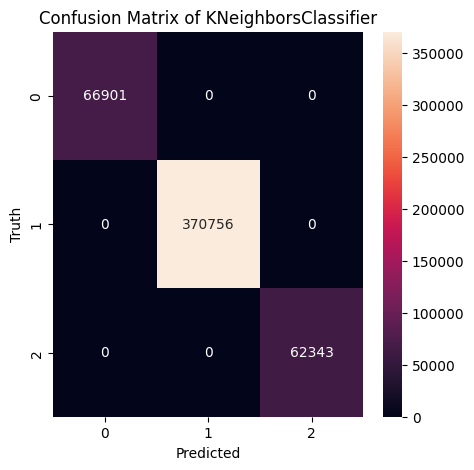



---		SVC		---

	Prediction time: 16.2226 seconds
	Accuracy: 1.000


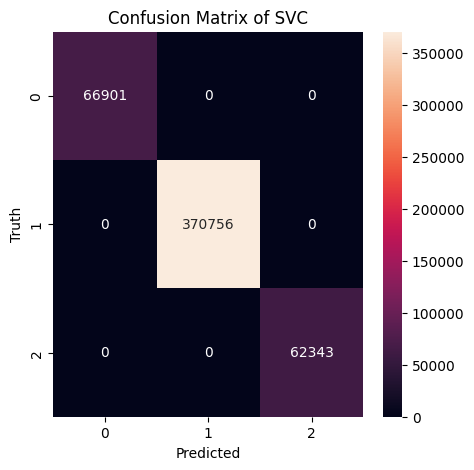



---		DecisionTreeClassifier		---

	Prediction time: 0.0358 seconds
	Accuracy: 1.000


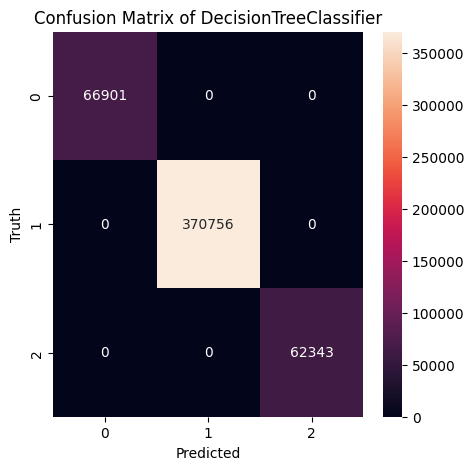



---		GaussianNB		---

	Prediction time: 0.1249 seconds
	Accuracy: 0.975


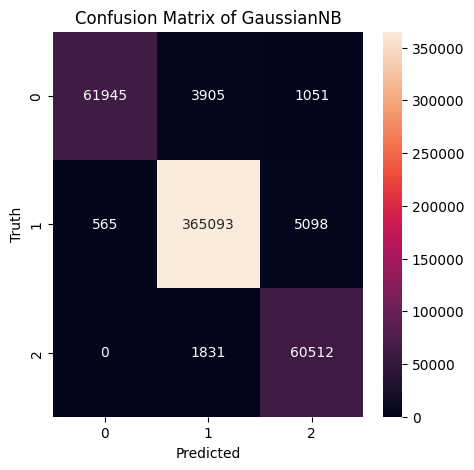



---		SGDClassifier		---

	Prediction time: 0.0320 seconds
	Accuracy: 0.998


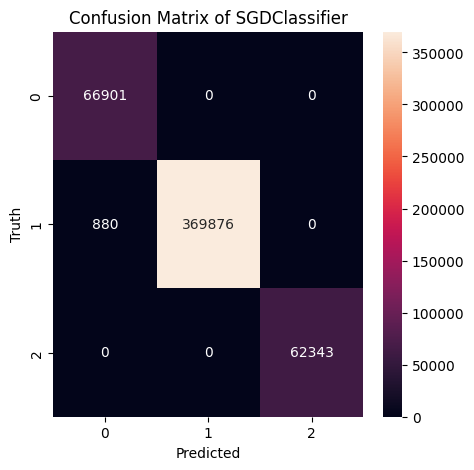

In [10]:
test(xts, yts)

#### Features importance evaluation

In [11]:
from sklearn.inspection import permutation_importance

def feature_importance_histogram(importances, colors, feature_names=None, title=None):
    """
    Plots a histogram of feature importances.
    Parameters
    ----------
    importances: list or array-like
        The importance scores for each feature.
    feature_names: list of str, optional
        Names of the features to use as x-axis labels.
    title : str, optional
        The title of the plot.
    """
    n_features = len(importances)
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(n_features)]

    plt.barh(
        range(n_features),
        importances[::-1],
        tick_label=feature_names,
        color=colors[:n_features][::-1],
        linewidth=1.2,
        alpha=0.7,
    )
    plt.xlabel("Feature")
    plt.ylabel("Importance score")
    plt.title(title)
    plt.xticks(fontsize=8)
    plt.show()

# Calculate and plot feature importances for each classifier
def feature_importance(xts, yts):
    for clf in clfs:
        results = permutation_importance(clf, xts, yts, n_repeats=10, n_jobs=-1, random_state=0)
        importances = results.importances_mean
        print("Importances:", np.round(importances, 3))
        if xts.shape[1] == 6:
            feature_names=["Characters", "Digits", "Symbols", "Uppercase", "Lowercase", "Unique"]
            colors = ["mediumorchid", "slateblue", "skyblue", "lightgreen", "gold", "tomato"]
        elif xts.shape[1] == 5:
            feature_names=["Digits", "Symbols", "Uppercase", "Lowercase", "Unique"]
            colors= ["slateblue", "skyblue", "lightgreen", "gold", "tomato"]
        feature_importance_histogram(importances, colors, feature_names[::-1], title=f"Features importances {clf.__class__.__name__}")

Importances: [0.417 0.    0.    0.    0.    0.   ]


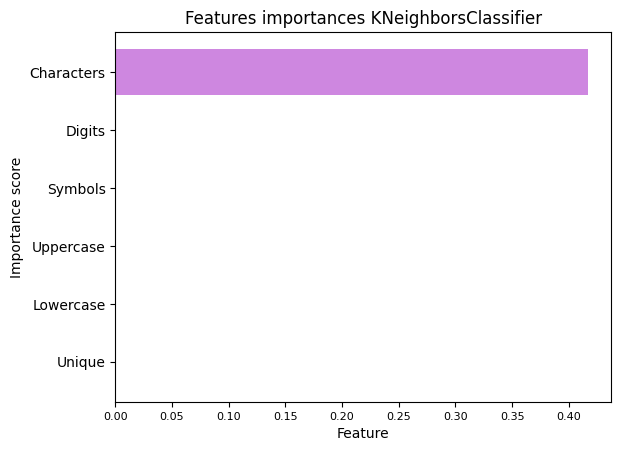

Importances: [0.417 0.    0.    0.    0.    0.   ]


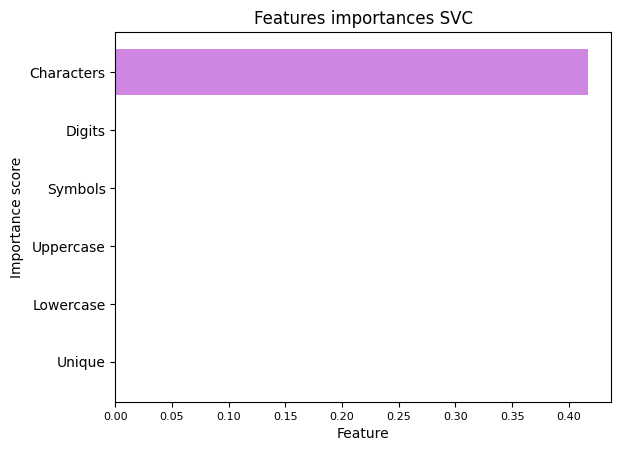

Importances: [0.417 0.    0.    0.    0.    0.   ]


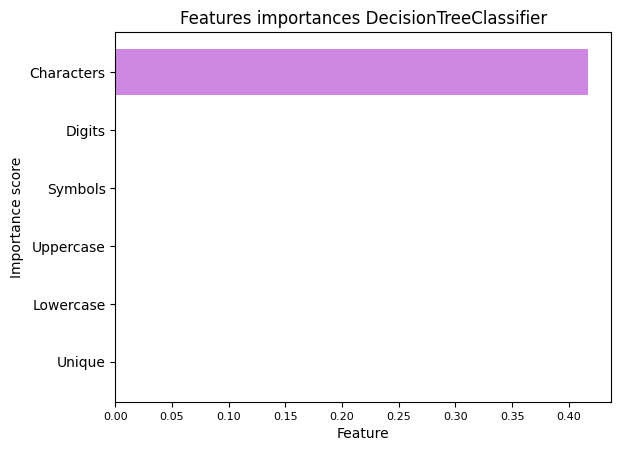

Importances: [0.298 0.014 0.009 0.054 0.02  0.   ]


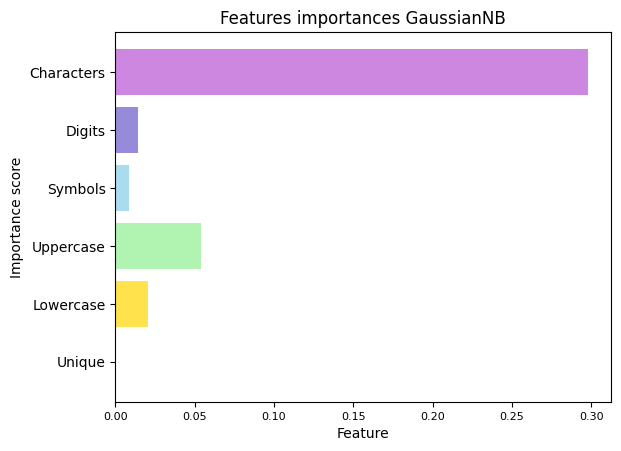

Importances: [ 0.416  0.006 -0.    -0.     0.003  0.   ]


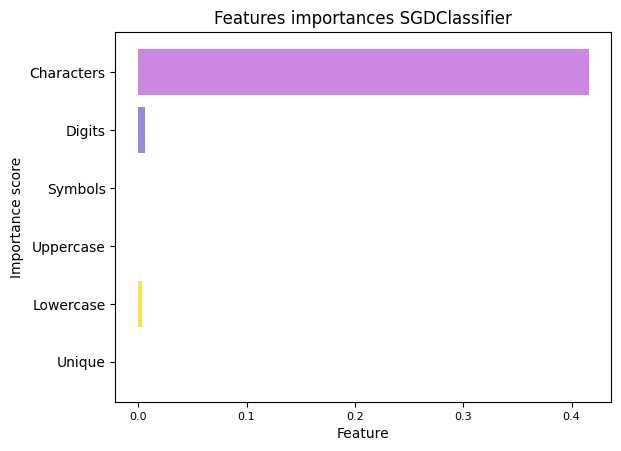

In [12]:
feature_importance(xts, yts)

#### Tests with Digits, Symbols, Upper, Lower and Unique characters as Features.

In [13]:
# Split the dataset into features and target variable
xtr = np.array([digits_train_norm, symbols_train_norm, upper_train_norm, lower_train_norm, unique_chars_train]).T
xts = np.array([digits_test_norm, symbols_test_norm, upper_test_norm, lower_test_norm, unique_chars_test]).T

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0752 seconds


---		SVC		---

	Training time:	 25.8703 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0196 seconds


---		GaussianNB		---

	Training time:	 0.0090 seconds


---		SGDClassifier		---

	Training time:	 0.4068 seconds




---		KNeighborsClassifier		---

	Prediction time: 53.3409 seconds
	Accuracy: 0.984


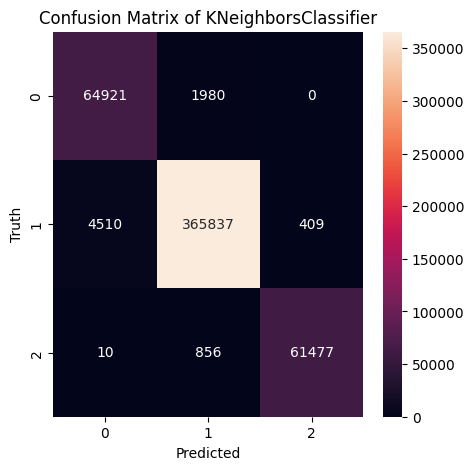



---		SVC		---

	Prediction time: 608.4875 seconds
	Accuracy: 0.903


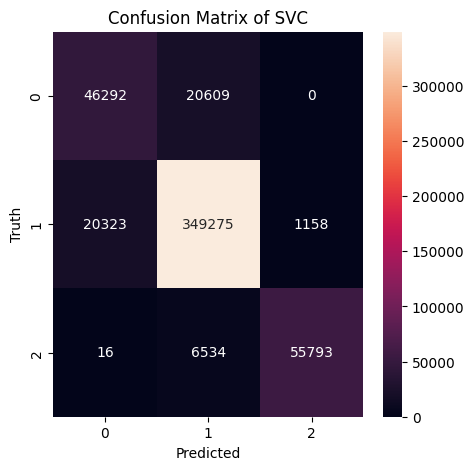



---		DecisionTreeClassifier		---

	Prediction time: 0.0374 seconds
	Accuracy: 0.875


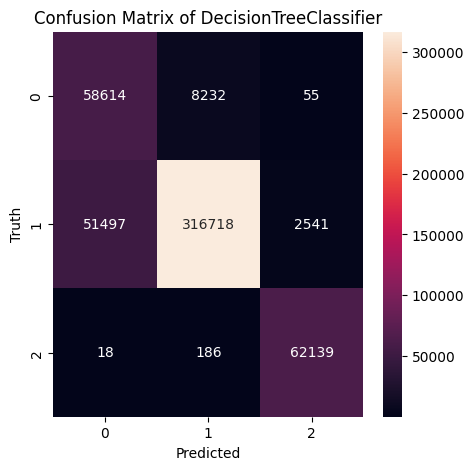



---		GaussianNB		---

	Prediction time: 0.0988 seconds
	Accuracy: 0.862


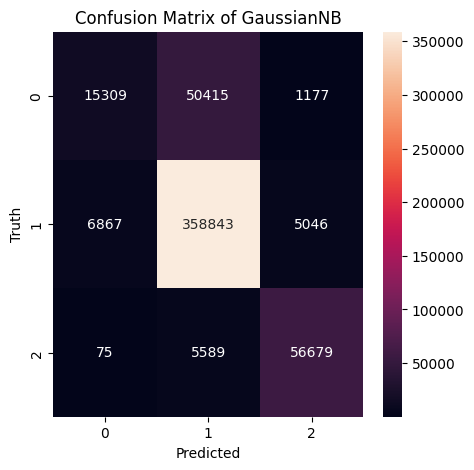



---		SGDClassifier		---

	Prediction time: 0.0294 seconds
	Accuracy: 0.863


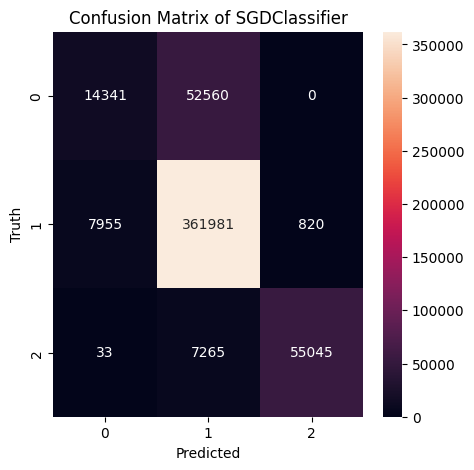

In [14]:
# Fit each classifier, make predictions, and evaluate performance
test(xts, yts)

Importances: [0.192 0.009 0.068 0.224 0.223]


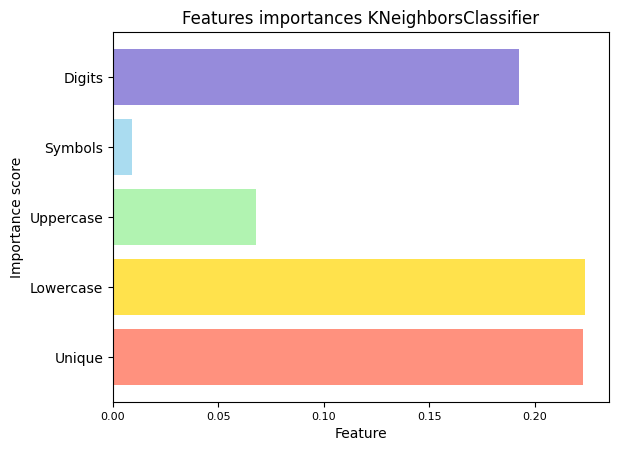

Importances: [0.025 0.001 0.004 0.017 0.292]


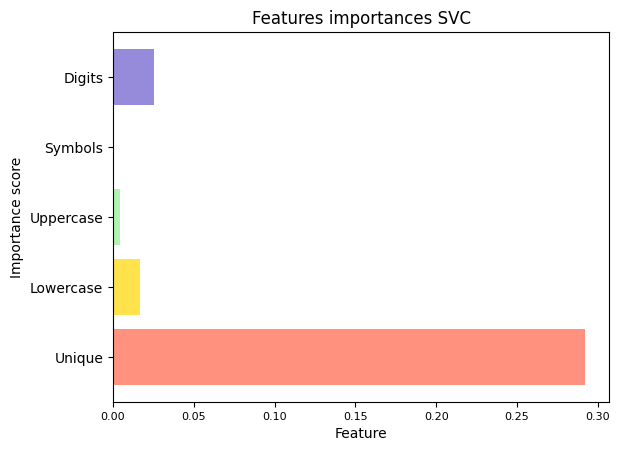

Importances: [0.078 0.018 0.189 0.014 0.134]


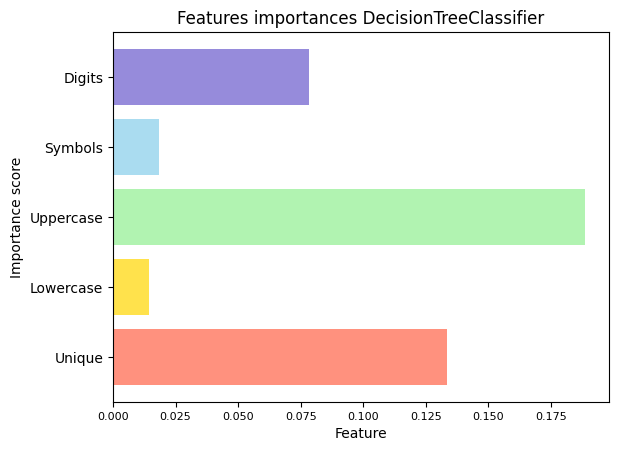

Importances: [0.007 0.011 0.068 0.007 0.115]


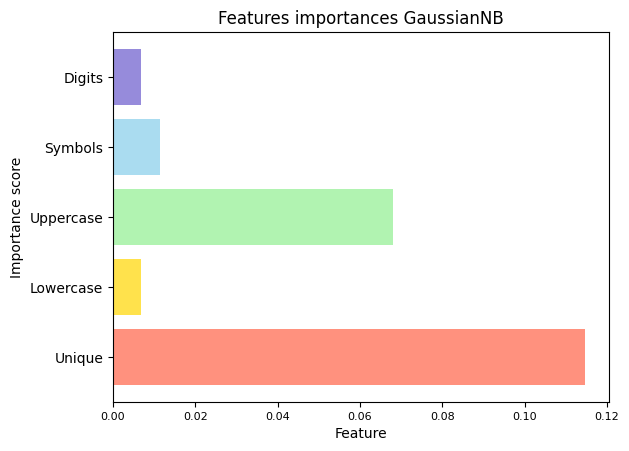

Importances: [ 0.053  0.001 -0.     0.005  0.209]


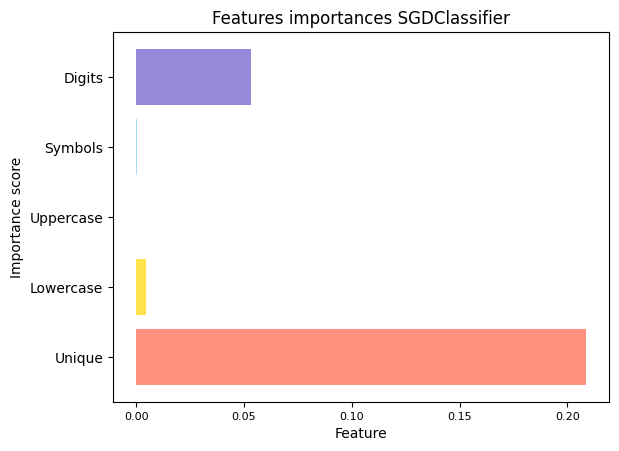

In [15]:
# Calculate and plot feature importances for each classifier
feature_importance(xts, yts)

#### Tests with only Password Length as a Feature.

In [16]:
# Split the dataset into features and target variable
xtr = np.array([pass_length_train]).T
xts = np.array([pass_length_test]).T

train(xtr, ytr)



---		KNeighborsClassifier		---

	Training time:	 0.0344 seconds


---		SVC		---

	Training time:	 0.1599 seconds


---		DecisionTreeClassifier		---

	Training time:	 0.0072 seconds


---		GaussianNB		---

	Training time:	 0.0029 seconds


---		SGDClassifier		---

	Training time:	 0.3201 seconds




---		KNeighborsClassifier		---

	Prediction time: 84.1516 seconds
	Accuracy: 1.000


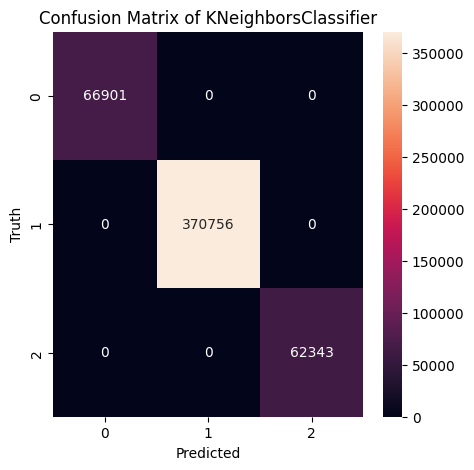



---		SVC		---

	Prediction time: 2.2418 seconds
	Accuracy: 1.000


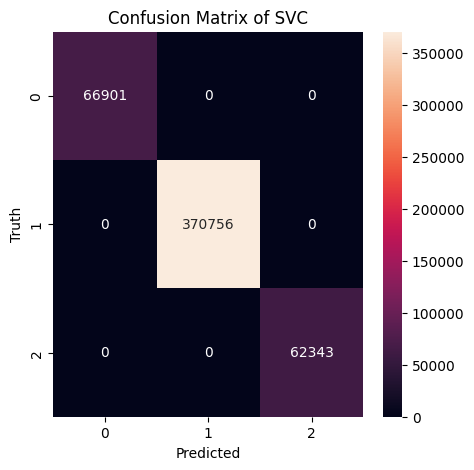



---		DecisionTreeClassifier		---

	Prediction time: 0.0264 seconds
	Accuracy: 1.000


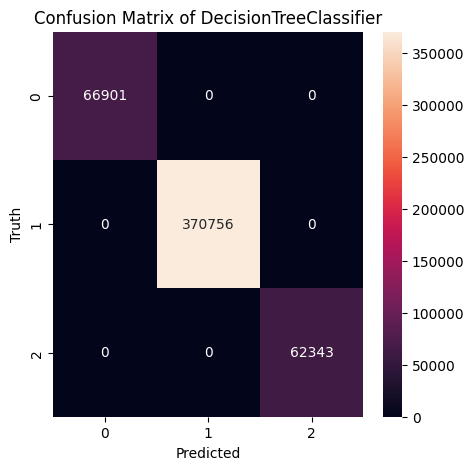



---		GaussianNB		---

	Prediction time: 0.0484 seconds
	Accuracy: 1.000


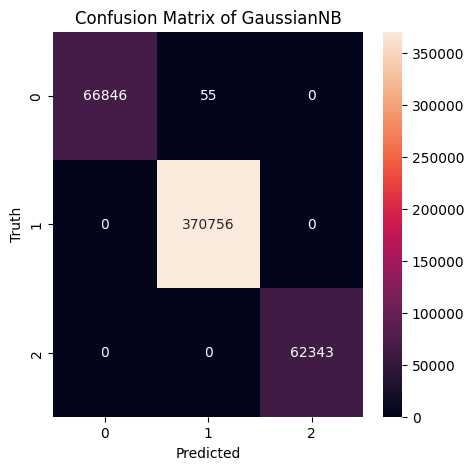



---		SGDClassifier		---

	Prediction time: 0.0355 seconds
	Accuracy: 1.000


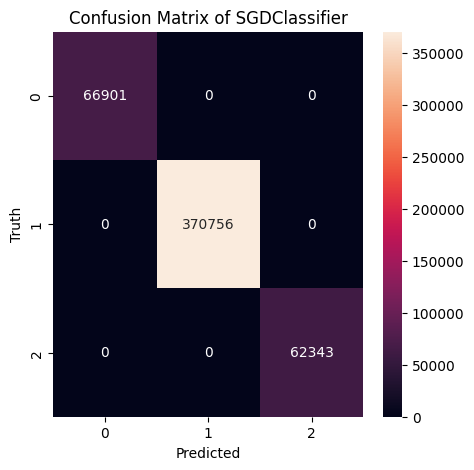

In [17]:
# Fit each classifier, make predictions, and evaluate performance
test(xts, yts)

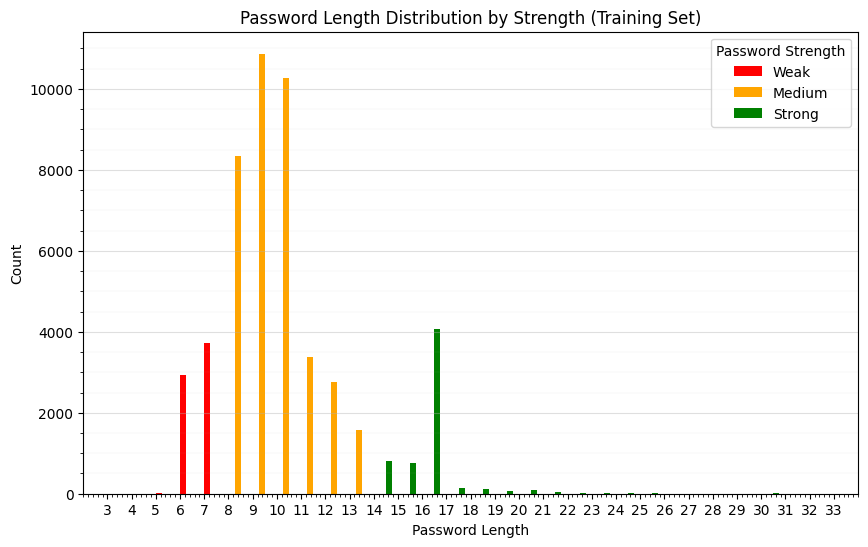

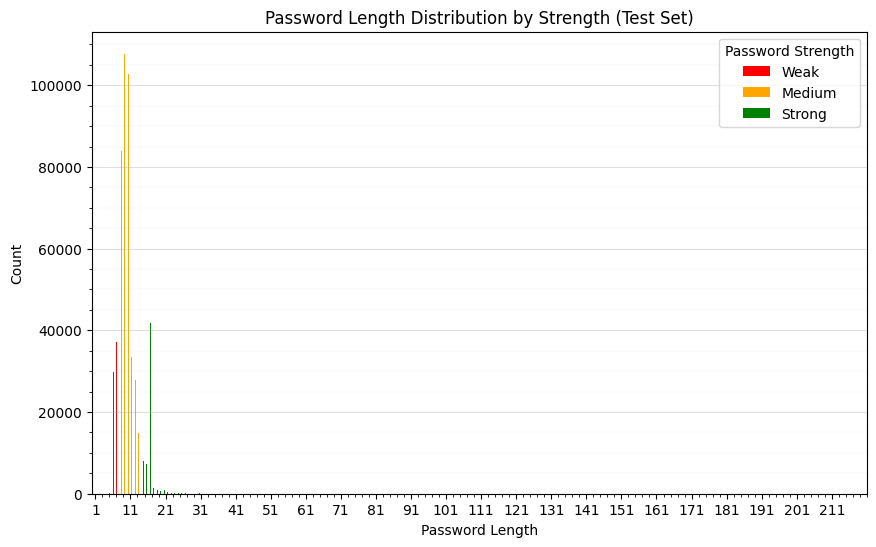

In [ ]:
def plot_dataset(x, y, title):
    plt.figure(figsize=(10, 6))
    classes = np.unique(y) 
    colors = ["red", "orange", "green", "blue", "purple", "cyan", "magenta"]
    all_lengths = x[:, 0]
    min_len = int(all_lengths.min())
    max_len = int(all_lengths.max())
    bin_edges = np.arange(min_len, max_len + 2)  # one bin per length

    width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)
    legend_names = ["Weak", "Medium", "Strong"]

    for i, k in enumerate(classes):
        lengths = x[y == k, 0]
        hist, _ = np.histogram(lengths, bins=bin_edges)
        plt.bar(
            bin_edges[:-1] + i * width,
            hist,
            width=width,
            color=colors[i % len(colors)],
            align="edge",
            label=legend_names[i],
        )
    plt.xlabel("Password Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(title="Password Strength")
    plt.grid(axis="y", alpha=0.4)
    plt.minorticks_on()
    plt.grid(which="minor", axis="y", alpha=0.2, linewidth=0.3)
    plt.xlim(min_len - 1, max_len + 1)
    plt.xticks(np.arange(min_len, max_len + 1, step=max(1, (max_len-min_len)//20)))
    plt.show()

# Plot the distributions of password lengths for training and test sets
plot_dataset(xtr, ytr, title="Password Length Distribution by Strength (Training Set)")
plot_dataset(xts, yts, title="Password Length Distribution by Strength (Test Set)")